<a href="https://colab.research.google.com/github/valceven/AliacSearchAlgo/blob/master/ISCapstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files.upload()  # Upload your kaggle.json here

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ceven7","key":"55bac6f5322be9a379ab058260452d7e"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [13]:
# get data from roboflow

# !pip install roboflow

# from roboflow import Roboflow
# rf = Roboflow(api_key="c32eqh0UKXsSvs8U2Iga")
# project = rf.workspace("haqqi").project("chicken-disease-avk9p")
# version = project.version(1)
# dataset = version.download("folder")

In [23]:
import os

os.listdir('Chicken-Disease-1/train')

['NewCastleDisease', 'Salmonella', 'Coccidiosis', 'Healthy']

In [25]:
import os
from pathlib import Path

path = 'Chicken-Disease-1'

def count_images_in_folder(folder_path):
    total = 0
    for root, dirs, files in os.walk(folder_path):
        total += len([f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    return total

cocci_count = count_images_in_folder(os.path.join(path, "Coccidiosis"))
salmo_count = count_images_in_folder(os.path.join(path, "Salmonella"))
healthy_count = count_images_in_folder(os.path.join(path, "Healthy"))
newcastle_count = count_images_in_folder(os.path.join(path, "NewCastleDisease"))

print(f"Cocci Images: {cocci_count}")
print(f"Salmo Images: {salmo_count}")
print(f"Healthy Images: {healthy_count}")
print(f"Newcastle Images: {newcastle_count}")

Cocci Images: 0
Salmo Images: 0
Healthy Images: 0
Newcastle Images: 0


In [26]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet_v2 import preprocess_input
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random

IMG_SIZE = (224, 224, 3)
BATCH_SIZE = 32

def preprocess_image(img, label):
    img = tf.keras.applications.resnet50.preprocess_input(img)
    return img, label

In [39]:
from tensorflow.keras.preprocessing import image_dataset_from_directory
import os

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 123  # Ensures reproducibility

# Train and validation from 'train' using split
train_ds = image_dataset_from_directory(
    os.path.join(path, "train"),
    validation_split=0.15,
    subset="training",
    seed=SEED,
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_ds = image_dataset_from_directory(
    os.path.join(path, "train"),
    validation_split=0.15,
    subset="validation",
    seed=SEED,
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

test_ds = image_dataset_from_directory(
    os.path.join(path, "test"),
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

# Optional: confirm class names and batch sizes
print("Classes:", train_ds.class_names)
print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Val batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

Found 5406 files belonging to 4 classes.
Using 4596 files for training.
Found 5406 files belonging to 4 classes.
Using 810 files for validation.
Found 2308 files belonging to 4 classes.
Classes: ['Coccidiosis', 'Healthy', 'NewCastleDisease', 'Salmonella']
Train batches: 144
Val batches: 26
Test batches: 73


In [35]:
train_ds = train_ds.map(preprocess_image)
val_ds = val_ds.map(preprocess_image)
test_ds = test_ds.map(preprocess_image)

print(len(train_ds))
print(len(test_ds))
print(len(val_ds))

# # Function to count occurrences of each class in the dataset
# def count_class_occurrences(dataset, class_names):
#     class_counts = {class_name: 0 for class_name in class_names}

#     for images, labels in dataset:
#         # Iterate through the batch and update counts based on class labels
#         for label in labels:
#             class_index = tf.argmax(label).numpy()  # Get the index of the max value in the one-hot label
#             class_name = class_names[class_index]
#             class_counts[class_name] += 1

#     return class_counts

# # Get the counts for train_ds
# train_class_counts = count_class_occurrences(train_ds, class_names)

# # Print the counts for each class in the training dataset
# print("Training Dataset Class Counts:")
# for class_name, count in train_class_counts.items():
#     print(f"{class_name}: {count}")

144
73
26


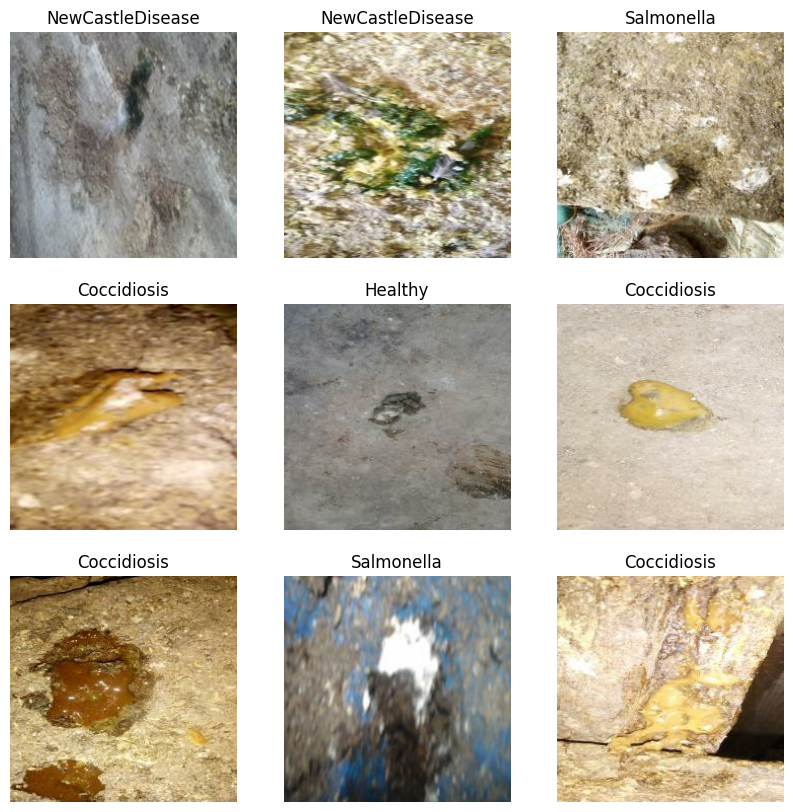

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Get a batch from your training dataset
class_names = train_ds.class_names
for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(9):  # Show 9 images
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))  # Convert to uint8 if needed
        label_index = np.argmax(labels[i])  # Get the index of the highest score
        plt.title(class_names[label_index])
        plt.axis("off")

In [42]:

from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

base_model = ResNet50V2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet",
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(4, activation='softmax')
])


model.summary()

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,837,540 (90.93 MB)

 Trainable params: 272,740 (1.04 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=['accuracy']
)

model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3,
    callbacks=[EarlyStopping(patience=3)]
)

Epoch 1/3
  7/144 ━━━━━━━━━━━━━━━━━━━━ 11:55 5s/step - accuracy: 0.2892 - loss: 79.4202

In [ ]:
base_model.trainable = True

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(train_ds,
          validation_data=val_ds,
          epochs=15,
          callbacks=[EarlyStopping(patience=3)]
          )

In [ ]:
model.evaluate(test_ds)

In [25]:
model.save('fine_tuned.h5')
from google.colab import files
files.download("fine_tuned.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# from google.colab import files

# uploaded = files.upload()
# !unzip model_folder.zip -d model_folder

Saving preprocessed_image21.h5 to preprocessed_image21.h5
unzip:  cannot find or open model_folder.zip, model_folder.zip.zip or model_folder.zip.ZIP.


In [ ]:
# from tensorflow.keras.models import load_model

# model = load_model("preprocessed_image21.h5")

In [ ]:
import numpy as np

preds = model.predict(test_ds)
y_pred = np.argmax(preds, axis=1)  # Convert from one-hot to class indices

y_true = []
for _, label in test_ds.unbatch():
    y_true.append(np.argmax(label.numpy()))  # Convert one-hot to index
y_true = np.array(y_true)


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)  # Replace with your class names
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

print("Predicted:", y_pred[:10])
print("True     :", y_true[:10])
# Accuracy
accuracy = np.mean(y_pred == y_true)
print(f"Manual accuracy: {accuracy:.2%}")
